In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

from scipy.cluster.hierarchy import linkage, dendrogram

In [5]:
data = load_wine()
X = data.data

x_scaled = StandardScaler().fit_transform(X)
x_scaled

array([[ 1.51861254, -0.5622498 ,  0.23205254, ...,  0.36217728,
         1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, ...,  0.40605066,
         1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, ...,  0.31830389,
         0.78858745,  1.39514818],
       ...,
       [ 0.33275817,  1.74474449, -0.38935541, ..., -1.61212515,
        -1.48544548,  0.28057537],
       [ 0.20923168,  0.22769377,  0.01273209, ..., -1.56825176,
        -1.40069891,  0.29649784],
       [ 1.39508604,  1.58316512,  1.36520822, ..., -1.52437837,
        -1.42894777, -0.59516041]], shape=(178, 13))

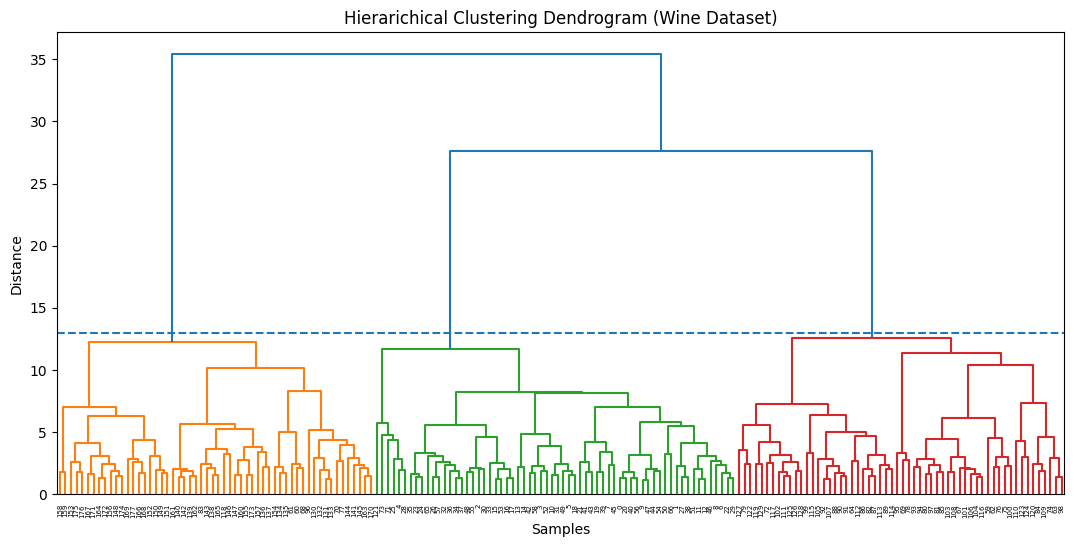

In [10]:
Z = linkage(x_scaled, method='ward')

plt.figure(figsize=(13,6))
dendrogram(Z)
plt.title('Hierarichical Clustering Dendrogram (Wine Dataset)')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.axhline(y=13, linestyle='--')
plt.show()

In [12]:
hc = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)
clusters_labels = hc.fit_predict(x_scaled)

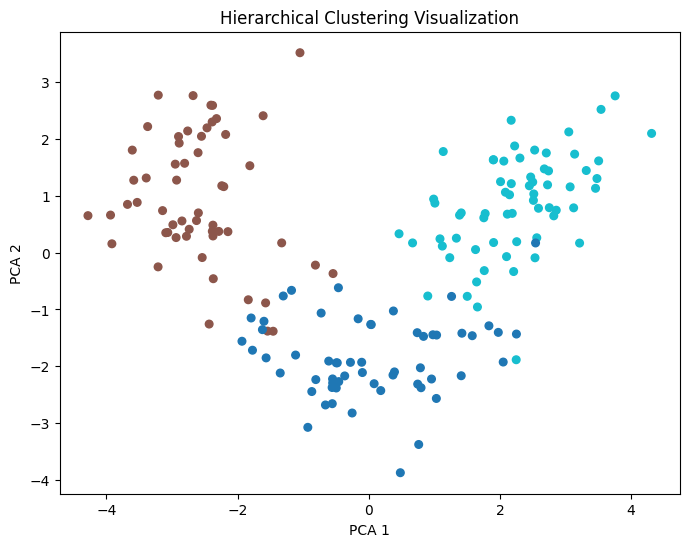

In [16]:
pca = PCA(n_components=2, random_state=42)
x_pca = pca.fit_transform(x_scaled)

plt.figure(figsize=(8,6))
plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=clusters_labels,
    cmap='tab10',
    s=30,
)
plt.title('Hierarchical Clustering Visualization')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [26]:
print('Cluster Distribution: ')
print(pd.Series(clusters_labels).value_counts())

Cluster Distribution: 
2    64
0    58
1    56
Name: count, dtype: int64
